# Snake

In [1]:
from IPython.display import clear_output
import numpy as np
from  tqdm import trange
import matplotlib.pyplot as plt
import random
import tensorflow as tf
import os

#set the path to the environments one folder up
os.chdir('..')

import environments_partially_observable 
from agent import Agent
import algorithms.actor_critic as ac
import algorithms.dqn as dqn
from replay_buffer import ReplayBuffer

os.chdir('partially_observable')


tf.random.set_seed(0)
random.seed(0)
np.random.seed(0)

2026-03-13 18:39:02.099512: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 18:39:02.179179: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773423542.193178   25764 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773423542.197825   25764 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773423542.271582   25764 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Environment definition

In [2]:
%matplotlib inline
# function to standardize getting an env for the whole notebook

N = 2000

def get_env(n=N):
    # n is the number of boards that you want to simulate parallely
    # size is the size of each board, also considering the borders
    # mask for the partially observable, is the size of the local neighborhood
    size = 7
    e = environments_partially_observable.OriginalSnakeEnvironment(n, size, 2)
    return e
env_ = get_env()

GAMMA = .99
ITERATIONS = 20000
SAVE_FREQUENCY = 2500

RESULTS_PATH = "results"


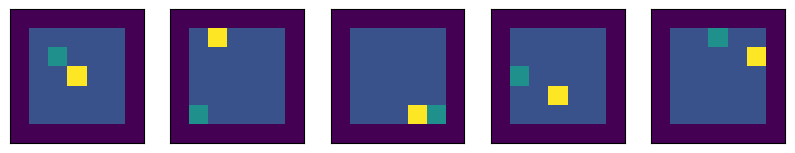

In [3]:
fig,axs=plt.subplots(1,min(len(env_.boards), 5), figsize=(10,3))
for ax, board in zip(axs, env_.boards):
    ax.get_yaxis().set_visible(False)
    ax.get_xaxis().set_visible(False)
    ax.imshow(board, origin="lower")

## Model 1

In [4]:
optimizer = tf.keras.optimizers.Adam(1e-4)

I0000 00:00:1773423544.121493   25764 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6655 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 SUPER, pci bus id: 0000:01:00.0, compute capability: 8.9


In [5]:
logic = dqn.create_logic(state_shape=env_.to_state().shape[1:], action_dim=4, n_boards=len(env_.boards), optimizer=optimizer, gamma=GAMMA)
agent = Agent(algorithm_logic=logic, algorithm_name="dqn_99", results_path=RESULTS_PATH, save_frequency=SAVE_FREQUENCY)

## Training

In [6]:
def train_buffer(agent, env_, buffer, MIN_BUFFER_SIZE=1000, BATCH_SIZE=64, TRAIN_EPOCHS=5, ITERATIONS=20000, SAVE_FREQUENCY=2500):
    progress_bar = trange(ITERATIONS)

    for iteration in progress_bar:
        # get current state of the boards
        state = env_.to_state()
        #sample action
        actions, _ = agent.get_action(state, training=True)

        rewards = env_.move(actions)
        new_state = tf.cast(env_.to_state(), dtype=tf.float32)

        done = tf.cast(tf.math.abs(rewards - (-0.1)) < 1e-5, tf.float32)

        buffer.push(state, actions.numpy(), rewards.numpy(), new_state.numpy(), done.numpy())

        dead_boards_indices = np.where(done.numpy().flatten() == 1.0)[0]
        for b_idx in dead_boards_indices:
            # get_board() adds Walls and Head, but NO Fruit
            new_board = env_.get_board()
            
            # MANUALLY ADD FRUIT so move() doesn't crash next step
            empty = np.argwhere(new_board == env_.EMPTY)
            if len(empty) > 0:
                f = empty[np.random.choice(len(empty))]
                new_board[f[0], f[1]] = env_.FRUIT
                
            env_.boards[b_idx] = new_board
            env_.bodies[b_idx] = [] # Clear body list

        if buffer.size < MIN_BUFFER_SIZE:
            continue

        iteration_losses = []
        iteration_rewards = []

        for _ in range(TRAIN_EPOCHS):
            # Sample a batch from history
            s_b, a_b, r_b, ns_b, d_b = buffer.sample(BATCH_SIZE)
            
            # Train the agent on the sampled batch
            loss_val, batch_reward = agent.train_step(s_b, a_b, r_b, ns_b, d_b)

            iteration_losses.append(loss_val)
            iteration_rewards.append(batch_reward)

        avg_loss = np.mean(iteration_losses)
        avg_reward = np.mean(iteration_rewards)

        agent.record_training_iteration(avg_loss=avg_loss, avg_reward=avg_reward)

        #if iteration % 20 == 0:
            #clear the output of the cell to update the plot
        #    clear_output(wait=True)
        #    recent_avg_reward = np.mean(agent.reward_history[-100:]) if agent.reward_history else 0
        #    progress_bar.set_description(f"Loss: {avg_loss:.4f} | Avg R: {recent_avg_reward:.3f}")

        if (iteration + 1) % SAVE_FREQUENCY == 0:
            agent.save_training_stats_binary()
            agent.save_training_plots()

## Training 1

In [7]:
buffer = ReplayBuffer(capacity=10000, state_shape=env_.to_state().shape[1:])
MIN_BUFFER_SIZE = 2000
BATCH_SIZE = 512

TRAIN_EPOCHS = 4

train_buffer(agent, env_, buffer, MIN_BUFFER_SIZE=MIN_BUFFER_SIZE, BATCH_SIZE=BATCH_SIZE, TRAIN_EPOCHS=TRAIN_EPOCHS, ITERATIONS=ITERATIONS, SAVE_FREQUENCY=SAVE_FREQUENCY)

  0%|          | 59/20000 [00:06<35:17,  9.42it/s] 


KeyboardInterrupt: 

In [ ]:
#clear memory after training
del env_
del agent
del buffer
del logic
del optimizer

## Training 2

In [ ]:
env_ = get_env()
#train the other model
optimizer = tf.keras.optimizers.Adam(1e-4)

In [ ]:
logic = ac.create_logic(state_shape=env_.to_state().shape[1:], action_dim=4, n_boards=len(env_.boards), optimizer=optimizer, gamma=GAMMA)
agent = Agent(algorithm_logic=logic, algorithm_name="actor_critic_99", results_path=RESULTS_PATH, save_frequency=SAVE_FREQUENCY)

In [ ]:
buffer = ReplayBuffer(capacity=10000, state_shape=env_.to_state().shape[1:])
MIN_BUFFER_SIZE = 2000
BATCH_SIZE = 512

TRAIN_EPOCHS = 4

train_buffer(agent, env_, buffer, MIN_BUFFER_SIZE=MIN_BUFFER_SIZE, BATCH_SIZE=BATCH_SIZE, TRAIN_EPOCHS=TRAIN_EPOCHS, ITERATIONS=ITERATIONS, SAVE_FREQUENCY=SAVE_FREQUENCY)